In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# K_Means
K-Means distance from centroid ke basis par groups banata hai, isliye aise complex shapes ko properly separate karna difficult ho sakta hai so used BDSCAN.

In [71]:
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)

In [72]:
df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])

In [73]:
df.head()

,Feature_1,Feature_2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [74]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [75]:
inertia = []
kmeans = range(1, 11)

In [76]:
for k in kmeans:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

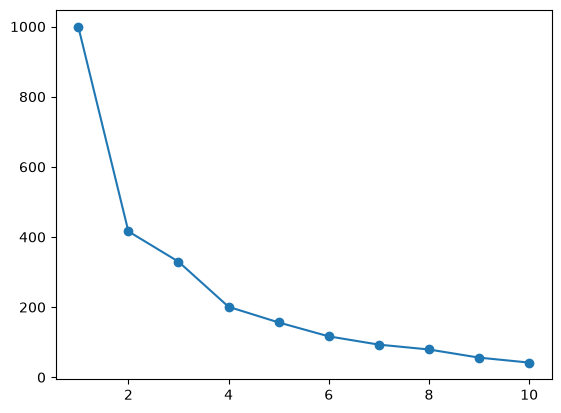

In [77]:
plt.plot(kmeans, inertia, marker="o")

In [78]:
kmean_final = KMeans(n_clusters=4, random_state=42)

In [79]:
cluster_label = kmean_final.fit_predict(X_scaled)

In [80]:
df["cluster"] = cluster_label
df.head()

,Feature_1,Feature_2,cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

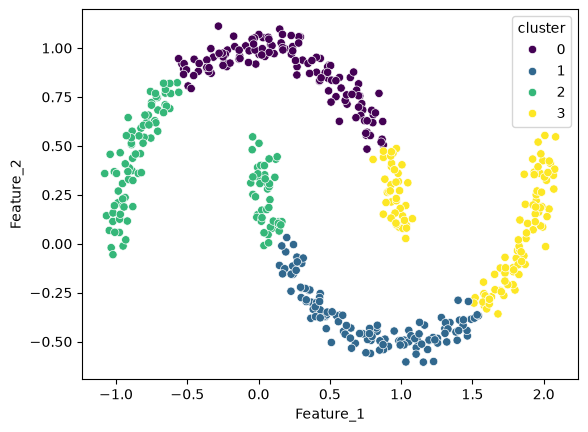

In [81]:
sns.scatterplot(x=df["Feature_1"],
                y=df["Feature_2"],
                hue=df["cluster"],
                palette="viridis")

# By using DBSCAN

In [83]:
from sklearn.cluster import DBSCAN

In [88]:
dbscan = DBSCAN(eps=0.3, min_samples=5)

In [89]:
dbscan_label = dbscan.fit_predict(X_scaled)

In [90]:
df["dbscan_cluster"] = dbscan_label
df.head()

,Feature_1,Feature_2,cluster,dbscan_cluster
0,0.830586,-0.447733,1,0
1,0.701678,0.816918,0,1
2,1.022080,-0.492571,1,0
3,-0.316765,0.953438,0,1
4,0.293226,1.057185,0,1


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

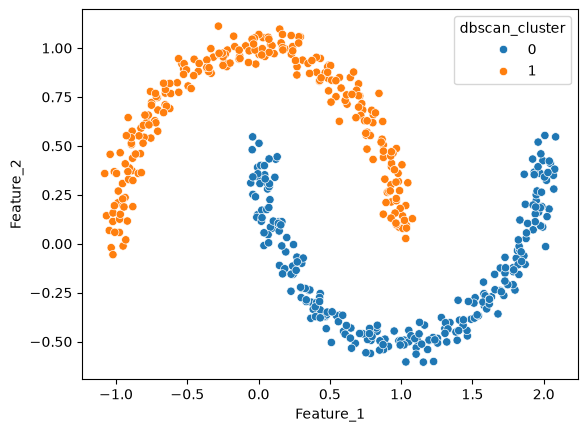

In [91]:
sns.scatterplot(x=df["Feature_1"],
                y = df["Feature_2"],
                hue=df["dbscan_cluster"],
                palette="tab10")